In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_inline import backend_inline
import torch.nn.functional as F
backend_inline.set_matplotlib_formats('svg')
import numpy as np

torch.backends.cudnn.benchmark = True

In [2]:
# 1. 定义数据预处理
# ToTensor 将图像转换为 [0.0, 1.0] 的张量
# Normalize 可选，通常用于加速训练收敛

#定义归一化参数
resnet_mean = [0.485, 0.456, 0.406]
resnet_std  = [0.229, 0.224, 0.225]
transform = transforms.Compose([#实际上不需要这步
    transforms.Resize((224, 224)),  # 调整图像大小
    transforms.ToTensor(),
    transforms.Normalize(mean=resnet_mean,
                         std=resnet_std)#(均值)，(标准差)
])

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


In [4]:
# 2. 载入训练集 (包含 50000 张图)
# train=True: torchvision 会自动找到并合并 data_batch_1 至 data_batch_5
ROOT_DIR = 'C:/Jupyter(Anaconda)/data'
train_dataset = datasets.CIFAR10(
    root=ROOT_DIR,
    train=True,
    download=False,
)
# --- 验证加载情况 ---
print(f"数据集大小: {len(train_dataset)}")

# 获取单个样本，验证是否返回 Tensor
image, label = train_dataset[0]


数据集大小: 50000


In [5]:
from torch.utils.data import Subset
# 若需要：直接切片（仅保留前 N 个，速度最快。需确保原数据已打乱顺序）
N = 50000  # 修改为你想要的训练样本数量
torch.manual_seed(42)#可复现
idx = torch.randperm(len(train_dataset))  # 生成随机排列索引

#包装为子集
train_subset = Subset(train_dataset, idx[:N])

#test1_subset=Subset(CIFAR_dataset, idx[N:])
test2_dataset = datasets.CIFAR10(
    root=ROOT_DIR,
    train=False,
    download=False,
)

In [6]:
import torch.nn as nn
import torchvision.models as models

#加载模型并移至 GPU
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet_model.fc = nn.Identity()  # 移除全连接层
resnet_model = resnet_model.to(device)
resnet_model.eval()

#冻结特征提取器的参数
for param in resnet_model.parameters():
    param.requires_grad = False

In [7]:
@torch.no_grad()
def fast_extract(imgs_np, batch_size=1024):
    """
    最快方案：
    - 一次性把全部图像转为 Tensor
    - 直接在 GPU 上分批推理，无 DataLoader 开销
    - FP16 autocast 加速
    - 预分配输出 tensor
    """
    resnet_model.eval()

    all_imgs = torch.from_numpy(imgs_np).permute(0, 3, 1, 2).float().div_(255.0)

    # 提前移到 GPU，循环内不再重复 .to(device)
    mean = torch.tensor(resnet_mean).view(1, 3, 1, 1).to(device)
    std  = torch.tensor(resnet_std).view(1, 3, 1, 1).to(device)

    N = all_imgs.shape[0]
    all_features = torch.zeros(N, 512, dtype=torch.float32)

    for i in range(0, N, batch_size):
        batch = all_imgs[i:i + batch_size].to(device)
        batch = F.interpolate(batch, size=(224, 224),
                              mode='bilinear', align_corners=False)
        batch.sub_(mean).div_(std)          # in-place 归一化，避免新建临时 tensor

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            feat = resnet_model(batch)

        all_features[i:i + batch_size] = feat.float().cpu()

    return all_features

In [8]:
#特征提取
#原耗时27s
print("正在提取训练集特征...")
X_train = fast_extract(train_dataset.data)
y_train=torch.tensor(train_dataset.targets)
print("正在提取验证集特征...")
X_test2 = fast_extract(test2_dataset.data)
y_test2=torch.tensor(test2_dataset.targets)

#标准化
feat_mean = X_train.mean(dim=0)
feat_std  = X_train.std(dim=0) + 1e-8          #防止除零

X_train = (X_train - feat_mean) / feat_std
X_test2 = (X_test2 - feat_mean) / feat_std     #必须用训练集统计量归一化测试集

print(f"X_train 特征形状: {X_train.shape}")
print(f"X_test1 特征形状: {X_test2.shape}")

正在提取训练集特征...
正在提取验证集特征...
X_train 特征形状: torch.Size([50000, 512])
X_test1 特征形状: torch.Size([10000, 512])


In [9]:
#创建特征数据集的 DataLoader
#TensorDataset 是 PyTorch 提供的最基础数据集类，用于将多个张量（如特征 X 和标签 y）打包成一个统一的数据集对象，使其能够与 DataLoader 配合使用。
from torch.utils.data import TensorDataset
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=250,
    shuffle=True,
    drop_last=True,                 # 丢弃最后不足 batch_size 的样本
    pin_memory=(device.type == "cuda")
)

test2_loader = DataLoader(
    TensorDataset(X_test2, y_test2),
    batch_size=500,
    shuffle=False,
    pin_memory=(device.type == "cuda")
)

In [10]:
class TrainModel(nn.Module):
    def __init__(self):
        super (TrainModel,self).__init__()
        self.net=nn.Sequential(
            #nn.Flatten(),
            nn.Linear(512,256),nn.ReLU(),
             nn.Linear(256,10)
        )
    def forward(self,X):
        y=self.net(X)
        return y   #输出


In [11]:
Model=TrainModel().to('cuda')
Model

TrainModel(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [12]:
%run MulClassSVM.ipynb
loss_fn1=MultiClassSVM()#美美使用自己写的loss
loss_fn2=nn.CrossEntropyLoss()

In [15]:
learning_rate=0.0001
optimizer=torch.optim.Adam(
    Model.parameters(),
    lr=learning_rate,
    weight_decay=0.0002
)
# 余弦退火调度器：随 epoch 平滑降低学习率
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)

Epoch [01/2]  Train Acc: 91.7780%  lr: 1.70e-06
Epoch [02/2]  Train Acc: 91.8180%  lr: 0.00e+00


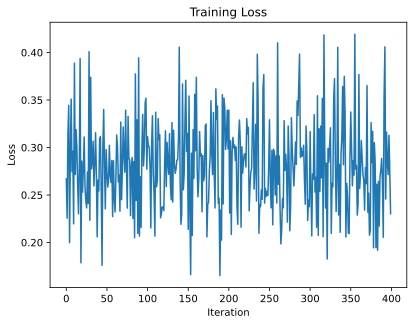

In [18]:
#训练网络
epochs=2
losses=[]
for epoch in range(epochs):
    Model.train() #训练模式
    correct,total=0,0
    for (x,y) in train_loader:#获取小批次x,y
        x,y=x.to(device),y.to(device)

        Pred=Model(x)#一次前向传播
        loss=0.8*loss_fn1(Pred,y)+0.2*loss_fn2(Pred,y)#计算损失函数
        losses.append(loss.item())
        optimizer.zero_grad()#清理上一轮滞留的梯度
        loss.backward()#一次反向传播
        optimizer.step()#优化内部参数
        correct    += (Pred.argmax(dim=1) == y).sum().item()
        total      += y.size(0)

    scheduler.step()
    train_acc  = correct    / total

    print(f"Epoch [{epoch+1:02d}/{epochs}]  "
          f"Train Acc: {100*train_acc:.4f}%  "
          f"lr: {scheduler.get_last_lr()[0]:.2e}")


# 绘制损失曲线
Fig = plt.figure()
plt.plot(range(len(losses)), losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
def evaluate(loader):
    """返回在给定 loader 上的准确率"""
    Model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = Model(X_batch).argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += y_batch.size(0)
    return correct / total

print("正在评估测试集...")#88.22% 22epochs
print(f"测试集准确率：{evaluate(test2_loader)*100:.4f}%")

正在评估测试集...
测试集准确率：88.2200%


In [20]:
torch.save(Model.state_dict(), "best_Conv+MLP.pth")